In [ ]:
!pip install geoopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.1 MB/s eta 0:00:00


Final Visualization of Euclidean Model:


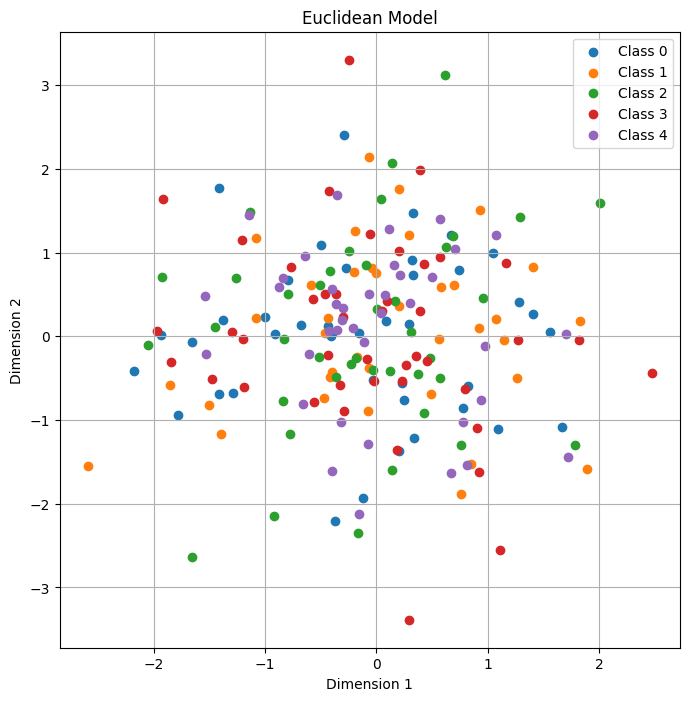

Final Visualization of Hyperbolic Model:


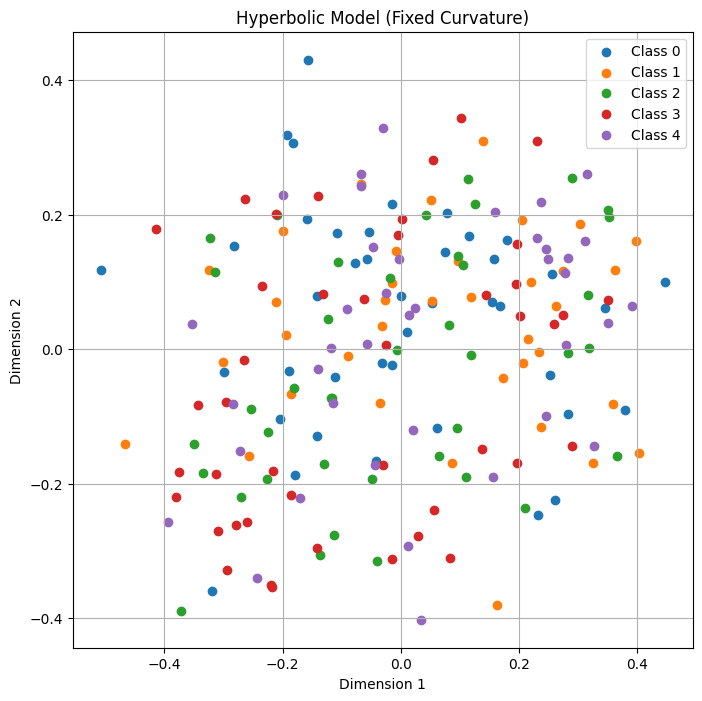

Final Visualization of Dynamic Hyperbolic Model:


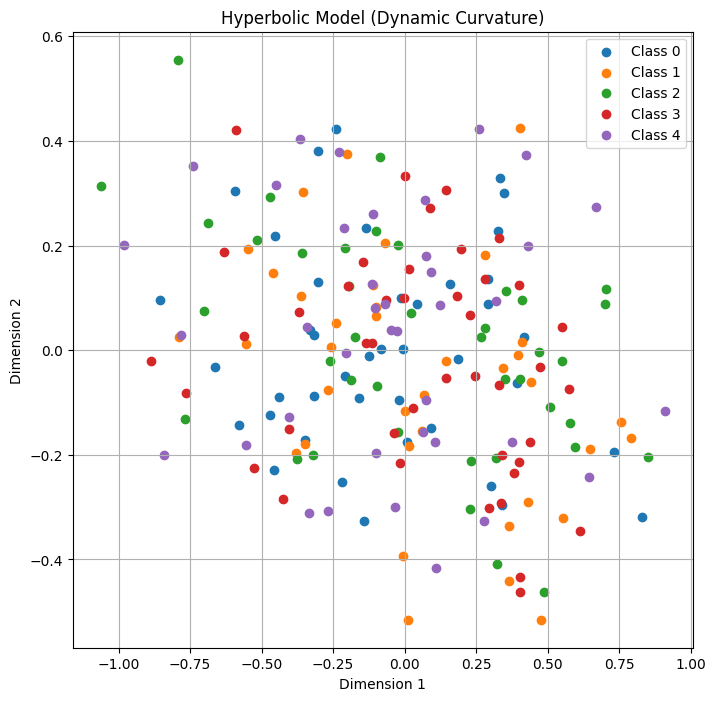

Analyzing Hyperbolic Embeddings:
Distance Correlation (Input vs Embedding): 0.6492
Analyzing Dynamic Hyperbolic Embeddings:
Distance Correlation (Input vs Embedding): 0.6674


In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances


# Mobius Linear Layer
class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)
        res = mobius_matvec(self.weight, x, k=k)
        res = self.manifold.mobius_add(res, self.bias)
        return res

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.c = new_c
        self.manifold = PoincareBall(c=new_c)


# Hyperbolic Layer
class HyperbolicLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicLayer, self).__init__()
        self.curvature = curvature
        self.encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.decoder = MobiusLinear(output_dim, input_dim, c=curvature)

    def forward(self, x):
        x_hyperbolic = self.encoder.manifold.expmap0(x)
        encoded = self.encoder(x_hyperbolic)
        decoded = self.decoder(encoded)
        x_euclidean = self.decoder.manifold.logmap0(decoded)
        return x_euclidean, encoded

    def update_curvature(self, new_c):
        """Update curvature for both encoder and decoder."""
        self.encoder.update_curvature(new_c)
        self.decoder.update_curvature(new_c)


# Neural Network with Hyperbolic Embedding
class HyperbolicNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, curvature=1.0, dynamic_curvature=False):
        super(HyperbolicNetwork, self).__init__()
        self.curvature = curvature
        self.dynamic_curvature = dynamic_curvature
        self.hyperbolic_layer = HyperbolicLayer(input_dim, hidden_dim, curvature=curvature)
        self.classifier = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, return_embeddings=False):
        x, embeddings = self.hyperbolic_layer(x)
        if return_embeddings:
            return embeddings
        return self.classifier(embeddings)

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.hyperbolic_layer.update_curvature(new_c)


# Neural Network with Euclidean Embedding
class EuclideanNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(EuclideanNetwork, self).__init__()
        self.linear1 = torch.nn.Linear(input_dim, hidden_dim)
        self.linear2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        return self.linear2(x)


# Train Model
def train_model(model, data, labels, epochs=100, lr=0.001, curvature_scaling=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []
    all_embeddings = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, labels)

        # Hyperbolic-specific: Regularize embedding norms
        if hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            norms = embeddings.norm(dim=1)
            horizon_loss = torch.mean((norms - 1.0) ** 2)
            loss += 0.1 * horizon_loss

            # Dynamic curvature adjustment
            if curvature_scaling and hasattr(model, "update_curvature"):
                new_c = model.curvature * 1.01  # Slightly increase curvature
                model.update_curvature(new_c)

        loss.backward()
        optimizer.step()
        all_losses.append(loss.item())

        # Save embeddings every 10 epochs
        if epoch % 10 == 0 and hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            all_embeddings.append(embeddings)

    return all_losses, all_embeddings


# Visualize Results
def visualize_results(data, labels, title):
    norms = data.norm(dim=1).detach()  # Detach tensor from computation graph
    data = data.detach().cpu()  # Detach and move to CPU for plotting
    labels = labels.detach().cpu()  # Detach and move to CPU for labels

    plt.figure(figsize=(8, 8))
    for label in torch.unique(labels):
        idx = (labels == label).nonzero(as_tuple=True)[0]
        plt.scatter(data[idx, 0], data[idx, 1], label=f"Class {label.item()}")
    plt.title(title)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.grid()
    plt.show()


# Analyze Embedding Quality
def analyze_embeddings(embeddings, data, labels):
    embeddings = embeddings.detach().cpu().numpy()  # Detach and convert to NumPy
    data = data.detach().cpu().numpy()  # Detach and convert to NumPy

    pairwise_input_distances = pairwise_distances(data)
    pairwise_embedding_distances = pairwise_distances(embeddings)

    # Correlation between input and embedding distances
    correlation = np.corrcoef(pairwise_input_distances.flatten(), pairwise_embedding_distances.flatten())[0, 1]
    print(f"Distance Correlation (Input vs Embedding): {correlation:.4f}")


# Main Experiment
def main():
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200
    epochs = 100

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    # Train Euclidean Model
    euclidean_model = EuclideanNetwork(input_dim, hidden_dim, output_dim)
    euclidean_losses, _ = train_model(euclidean_model, data, labels, epochs)

    # Train Hyperbolic Model (Fixed Curvature)
    hyperbolic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=1.0)
    hyperbolic_losses, hyperbolic_embeddings = train_model(hyperbolic_model, data, labels, epochs)

    # Train Hyperbolic Model (Dynamic Curvature)
    hyperbolic_dynamic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=0.5, dynamic_curvature=True)
    dynamic_losses, dynamic_embeddings = train_model(hyperbolic_dynamic_model, data, labels, epochs, curvature_scaling=True)

    # Visualize Embeddings
    print("Final Visualization of Euclidean Model:")
    visualize_results(data, labels, "Euclidean Model")
    print("Final Visualization of Hyperbolic Model:")
    visualize_results(hyperbolic_embeddings[-1], labels, "Hyperbolic Model (Fixed Curvature)")
    print("Final Visualization of Dynamic Hyperbolic Model:")
    visualize_results(dynamic_embeddings[-1], labels, "Hyperbolic Model (Dynamic Curvature)")

    # Compare Metrics
    print("Analyzing Hyperbolic Embeddings:")
    analyze_embeddings(hyperbolic_embeddings[-1], data, labels)
    print("Analyzing Dynamic Hyperbolic Embeddings:")
    analyze_embeddings(dynamic_embeddings[-1], data, labels)


if __name__ == "__main__":
    main()

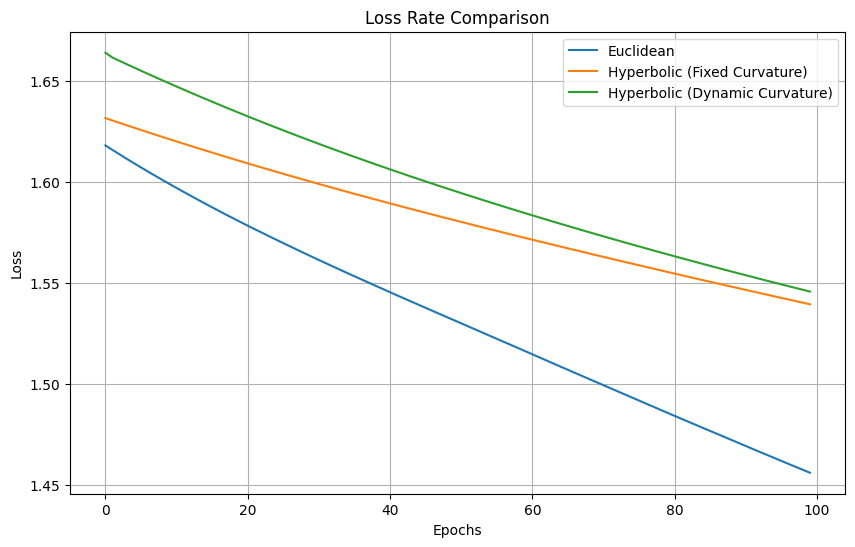

Clustering Comparison for Hyperbolic Model (Fixed Curvature):


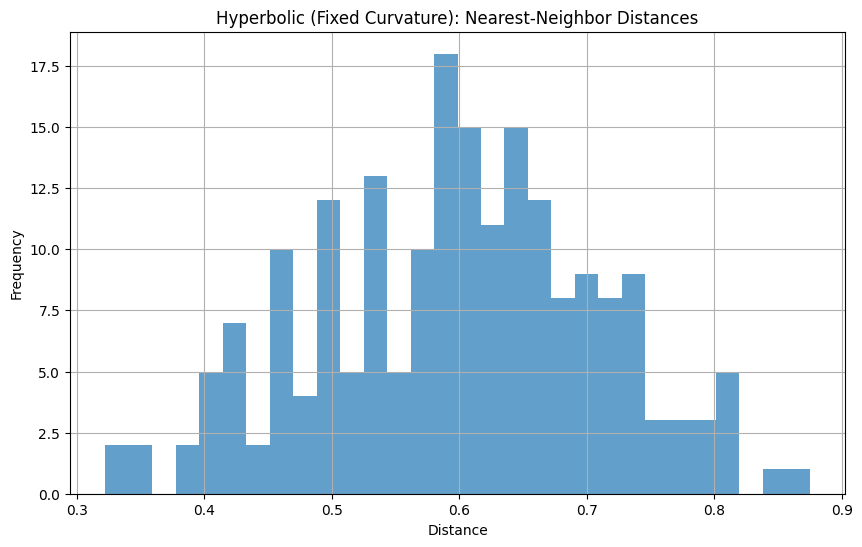

Clustering Comparison for Hyperbolic Model (Dynamic Curvature):


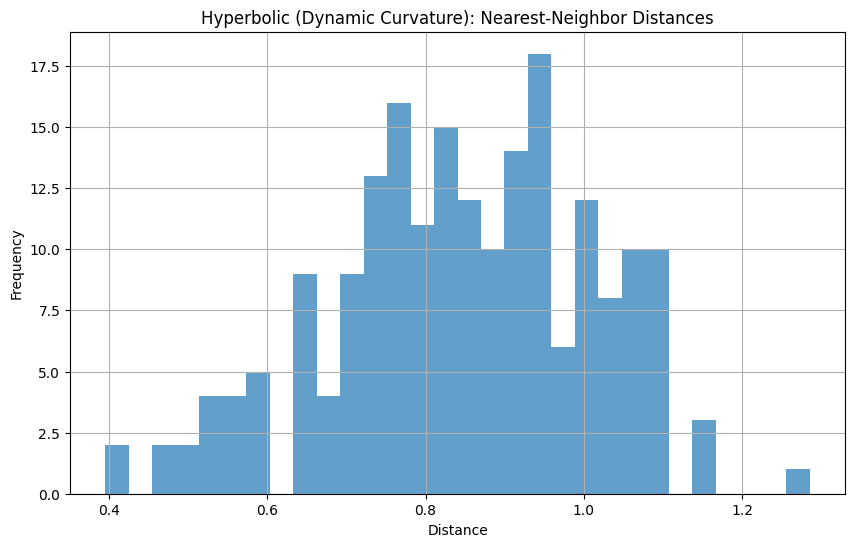

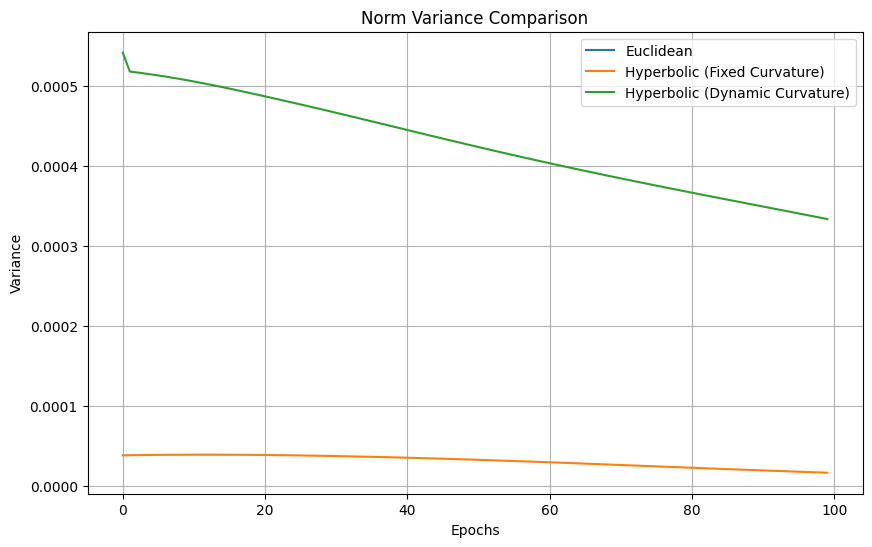

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances


# Mobius Linear Layer
class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)
        res = mobius_matvec(self.weight, x, k=k)
        res = self.manifold.mobius_add(res, self.bias)
        return res

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.c = new_c
        self.manifold = PoincareBall(c=new_c)


# Hyperbolic Layer
class HyperbolicLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicLayer, self).__init__()
        self.curvature = curvature
        self.encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.decoder = MobiusLinear(output_dim, input_dim, c=curvature)

    def forward(self, x):
        x_hyperbolic = self.encoder.manifold.expmap0(x)
        encoded = self.encoder(x_hyperbolic)
        decoded = self.decoder(encoded)
        x_euclidean = self.decoder.manifold.logmap0(decoded)
        return x_euclidean, encoded

    def update_curvature(self, new_c):
        """Update curvature for both encoder and decoder."""
        self.encoder.update_curvature(new_c)
        self.decoder.update_curvature(new_c)


# Neural Network with Hyperbolic Embedding
class HyperbolicNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, curvature=1.0, dynamic_curvature=False):
        super(HyperbolicNetwork, self).__init__()
        self.curvature = curvature
        self.dynamic_curvature = dynamic_curvature
        self.hyperbolic_layer = HyperbolicLayer(input_dim, hidden_dim, curvature=curvature)
        self.classifier = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, return_embeddings=False):
        x, embeddings = self.hyperbolic_layer(x)
        if return_embeddings:
            return embeddings
        return self.classifier(embeddings)

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.hyperbolic_layer.update_curvature(new_c)


# Neural Network with Euclidean Embedding
class EuclideanNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(EuclideanNetwork, self).__init__()
        self.linear1 = torch.nn.Linear(input_dim, hidden_dim)
        self.linear2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        return self.linear2(x)


# Train Model
def train_model(model, data, labels, epochs=100, lr=0.001, curvature_scaling=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []
    all_embeddings = []
    all_norm_variances = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, labels)

        # Hyperbolic-specific: Regularize embedding norms
        if hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            norms = embeddings.norm(dim=1)
            horizon_loss = torch.mean((norms - 1.0) ** 2)
            loss += 0.1 * horizon_loss

            # Dynamic curvature adjustment
            if curvature_scaling and hasattr(model, "update_curvature"):
                new_c = model.curvature * 1.01  # Slightly increase curvature
                model.update_curvature(new_c)

            # Track variance of norms
            norm_variance = torch.var(norms).item()
            all_norm_variances.append(norm_variance)

        loss.backward()
        optimizer.step()
        all_losses.append(loss.item())

        # Save embeddings every 10 epochs
        if epoch % 10 == 0 and hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            all_embeddings.append(embeddings)

    return all_losses, all_embeddings, all_norm_variances


# Compare Loss Rates
def plot_loss_rates(euclidean_losses, hyperbolic_losses, dynamic_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(euclidean_losses, label="Euclidean")
    plt.plot(hyperbolic_losses, label="Hyperbolic (Fixed Curvature)")
    plt.plot(dynamic_losses, label="Hyperbolic (Dynamic Curvature)")
    plt.title("Loss Rate Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


def plot_clustering(embeddings, labels, title="Clustering Comparison"):
    with torch.no_grad():
        # Convert embeddings to NumPy and compute pairwise distances
        embeddings = embeddings.detach().cpu().numpy()
        pairwise_dist = pairwise_distances(embeddings)

        # Replace diagonal (self-distances) with infinity to exclude them
        np.fill_diagonal(pairwise_dist, np.inf)

        # Compute nearest-neighbor distances
        nearest_distances = np.min(pairwise_dist, axis=1)

        # Filter out NaN or infinite values (if any)
        nearest_distances = nearest_distances[np.isfinite(nearest_distances)]

    if nearest_distances.size == 0:
        print(f"No valid nearest-neighbor distances found for {title}. Skipping plot.")
        return

    # Plot histogram of nearest-neighbor distances
    plt.figure(figsize=(10, 6))
    plt.hist(nearest_distances, bins=30, alpha=0.7, label=title)
    plt.title(f"{title}: Nearest-Neighbor Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

# Plot Variance in Embedding Norms
def plot_norm_variances(euclidean_variances, hyperbolic_variances, dynamic_variances):
    plt.figure(figsize=(10, 6))
    plt.plot(euclidean_variances, label="Euclidean")
    plt.plot(hyperbolic_variances, label="Hyperbolic (Fixed Curvature)")
    plt.plot(dynamic_variances, label="Hyperbolic (Dynamic Curvature)")
    plt.title("Norm Variance Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Variance")
    plt.legend()
    plt.grid()
    plt.show()


# Main Experiment
def main():
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200
    epochs = 100

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    # Train Euclidean Model
    euclidean_model = EuclideanNetwork(input_dim, hidden_dim, output_dim)
    euclidean_losses, _, euclidean_variances = train_model(euclidean_model, data, labels, epochs)

    # Train Hyperbolic Model (Fixed Curvature)
    hyperbolic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=1.0)
    hyperbolic_losses, hyperbolic_embeddings, hyperbolic_variances = train_model(hyperbolic_model, data, labels, epochs)

    # Train Hyperbolic Model (Dynamic Curvature)
    hyperbolic_dynamic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=0.5, dynamic_curvature=True)
    dynamic_losses, dynamic_embeddings, dynamic_variances = train_model(
        hyperbolic_dynamic_model, data, labels, epochs, curvature_scaling=True
    )

    # Plot Loss Rates
    plot_loss_rates(euclidean_losses, hyperbolic_losses, dynamic_losses)

    # Plot Clustering
    print("Clustering Comparison for Hyperbolic Model (Fixed Curvature):")
    plot_clustering(hyperbolic_embeddings[-1], labels, "Hyperbolic (Fixed Curvature)")
    print("Clustering Comparison for Hyperbolic Model (Dynamic Curvature):")
    plot_clustering(dynamic_embeddings[-1], labels, "Hyperbolic (Dynamic Curvature)")

    # Plot Variance in Embedding Norms
    plot_norm_variances(euclidean_variances, hyperbolic_variances, dynamic_variances)


if __name__ == "__main__":
    main()

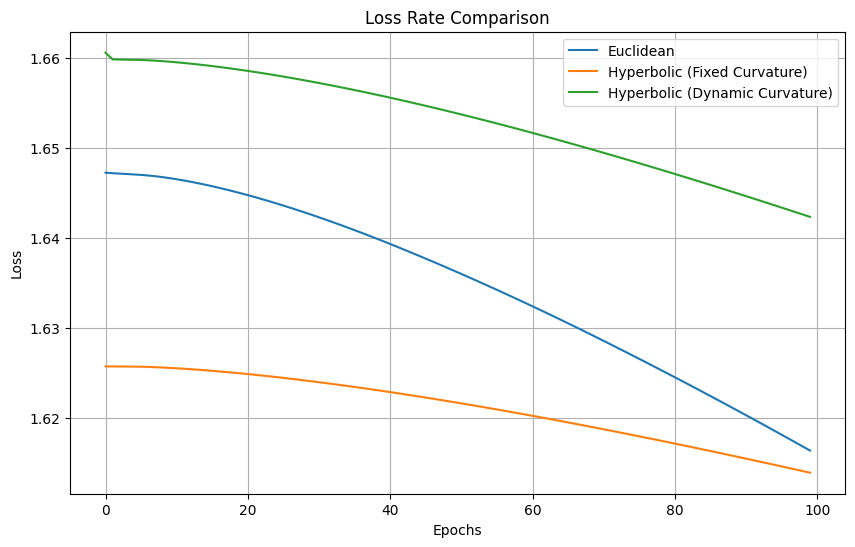

Clustering Comparison for Hyperbolic Model (Fixed Curvature):


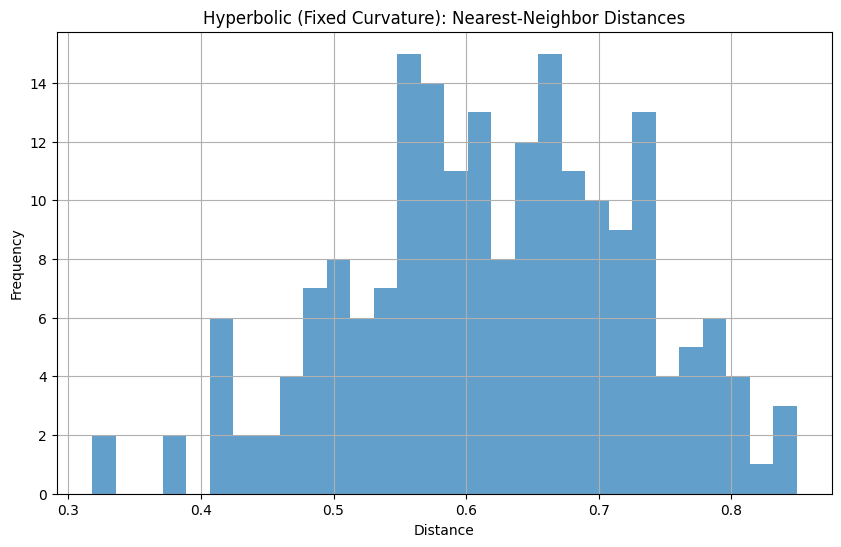

Clustering Comparison for Hyperbolic Model (Dynamic Curvature):


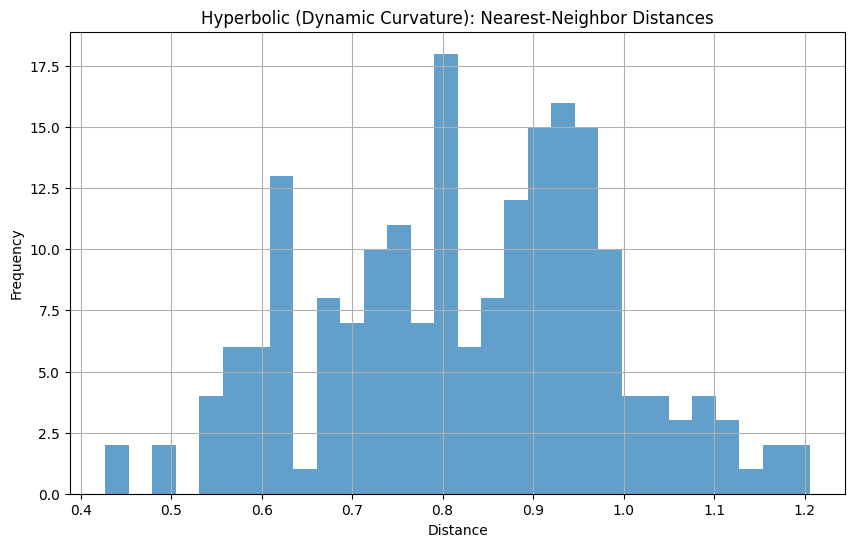

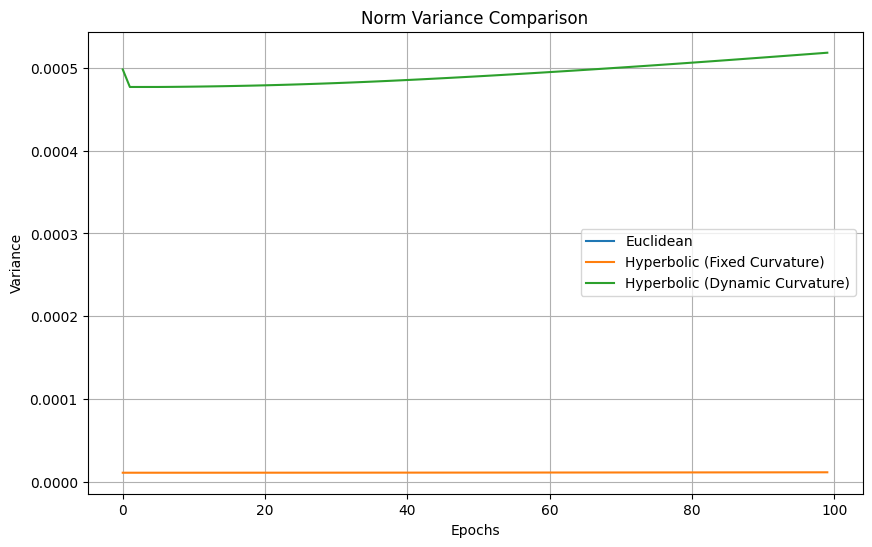

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances


# Mobius Linear Layer
class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)
        res = mobius_matvec(self.weight, x, k=k)
        res = self.manifold.mobius_add(res, self.bias)
        return res

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.c = new_c
        self.manifold = PoincareBall(c=new_c)


# Hyperbolic Layer
class HyperbolicLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicLayer, self).__init__()
        self.curvature = curvature
        self.encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.decoder = MobiusLinear(output_dim, input_dim, c=curvature)

    def forward(self, x):
        x_hyperbolic = self.encoder.manifold.expmap0(x)
        encoded = self.encoder(x_hyperbolic)
        decoded = self.decoder(encoded)
        x_euclidean = self.decoder.manifold.logmap0(decoded)
        return x_euclidean, encoded

    def update_curvature(self, new_c):
        """Update curvature for both encoder and decoder."""
        self.encoder.update_curvature(new_c)
        self.decoder.update_curvature(new_c)


# Neural Network with Hyperbolic Embedding
class HyperbolicNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, curvature=1.0, dynamic_curvature=False):
        super(HyperbolicNetwork, self).__init__()
        self.curvature = curvature
        self.dynamic_curvature = dynamic_curvature
        self.hyperbolic_layer = HyperbolicLayer(input_dim, hidden_dim, curvature=curvature)
        self.classifier = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, return_embeddings=False):
        x, embeddings = self.hyperbolic_layer(x)
        if return_embeddings:
            return embeddings
        return self.classifier(embeddings)

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.hyperbolic_layer.update_curvature(new_c)


# Neural Network with Euclidean Embedding
class EuclideanNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(EuclideanNetwork, self).__init__()
        self.linear1 = torch.nn.Linear(input_dim, hidden_dim)
        self.linear2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        return self.linear2(x)

# Train Model
def train_model(model, data, labels, epochs=100, lr=0.001, curvature_scaling=False):
    # Replace Adam with RAdam
    optimizer = torch.optim.RAdam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []
    all_embeddings = []
    all_norm_variances = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, labels)

        # Hyperbolic-specific: Regularize embedding norms
        if hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            norms = embeddings.norm(dim=1)
            horizon_loss = torch.mean((norms - 1.0) ** 2)
            loss += 0.1 * horizon_loss

            # Dynamic curvature adjustment
            if curvature_scaling and hasattr(model, "update_curvature"):
                new_c = model.curvature * 1.01  # Slightly increase curvature
                model.update_curvature(new_c)

            # Track variance of norms
            norm_variance = torch.var(norms).item()
            all_norm_variances.append(norm_variance)

        loss.backward()
        optimizer.step()
        all_losses.append(loss.item())

        # Save embeddings every 10 epochs
        if epoch % 10 == 0 and hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            all_embeddings.append(embeddings)

    return all_losses, all_embeddings, all_norm_variances

# Compare Loss Rates
def plot_loss_rates(euclidean_losses, hyperbolic_losses, dynamic_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(euclidean_losses, label="Euclidean")
    plt.plot(hyperbolic_losses, label="Hyperbolic (Fixed Curvature)")
    plt.plot(dynamic_losses, label="Hyperbolic (Dynamic Curvature)")
    plt.title("Loss Rate Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


def plot_clustering(embeddings, labels, title="Clustering Comparison"):
    with torch.no_grad():
        # Convert embeddings to NumPy and compute pairwise distances
        embeddings = embeddings.detach().cpu().numpy()
        pairwise_dist = pairwise_distances(embeddings)

        # Replace diagonal (self-distances) with infinity to exclude them
        np.fill_diagonal(pairwise_dist, np.inf)

        # Compute nearest-neighbor distances
        nearest_distances = np.min(pairwise_dist, axis=1)

        # Filter out NaN or infinite values (if any)
        nearest_distances = nearest_distances[np.isfinite(nearest_distances)]

    if nearest_distances.size == 0:
        print(f"No valid nearest-neighbor distances found for {title}. Skipping plot.")
        return

    # Plot histogram of nearest-neighbor distances
    plt.figure(figsize=(10, 6))
    plt.hist(nearest_distances, bins=30, alpha=0.7, label=title)
    plt.title(f"{title}: Nearest-Neighbor Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

# Plot Variance in Embedding Norms
def plot_norm_variances(euclidean_variances, hyperbolic_variances, dynamic_variances):
    plt.figure(figsize=(10, 6))
    plt.plot(euclidean_variances, label="Euclidean")
    plt.plot(hyperbolic_variances, label="Hyperbolic (Fixed Curvature)")
    plt.plot(dynamic_variances, label="Hyperbolic (Dynamic Curvature)")
    plt.title("Norm Variance Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Variance")
    plt.legend()
    plt.grid()
    plt.show()


# Main Experiment
def main():
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200
    epochs = 100

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    # Train Euclidean Model
    euclidean_model = EuclideanNetwork(input_dim, hidden_dim, output_dim)
    euclidean_losses, _, euclidean_variances = train_model(euclidean_model, data, labels, epochs)

    # Train Hyperbolic Model (Fixed Curvature)
    hyperbolic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=1.0)
    hyperbolic_losses, hyperbolic_embeddings, hyperbolic_variances = train_model(hyperbolic_model, data, labels, epochs)

    # Train Hyperbolic Model (Dynamic Curvature)
    hyperbolic_dynamic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=0.5, dynamic_curvature=True)
    dynamic_losses, dynamic_embeddings, dynamic_variances = train_model(
        hyperbolic_dynamic_model, data, labels, epochs, curvature_scaling=True
    )

    # Plot Loss Rates
    plot_loss_rates(euclidean_losses, hyperbolic_losses, dynamic_losses)

    # Plot Clustering
    print("Clustering Comparison for Hyperbolic Model (Fixed Curvature):")
    plot_clustering(hyperbolic_embeddings[-1], labels, "Hyperbolic (Fixed Curvature)")
    print("Clustering Comparison for Hyperbolic Model (Dynamic Curvature):")
    plot_clustering(dynamic_embeddings[-1], labels, "Hyperbolic (Dynamic Curvature)")

    # Plot Variance in Embedding Norms
    plot_norm_variances(euclidean_variances, hyperbolic_variances, dynamic_variances)


if __name__ == "__main__":
    main()

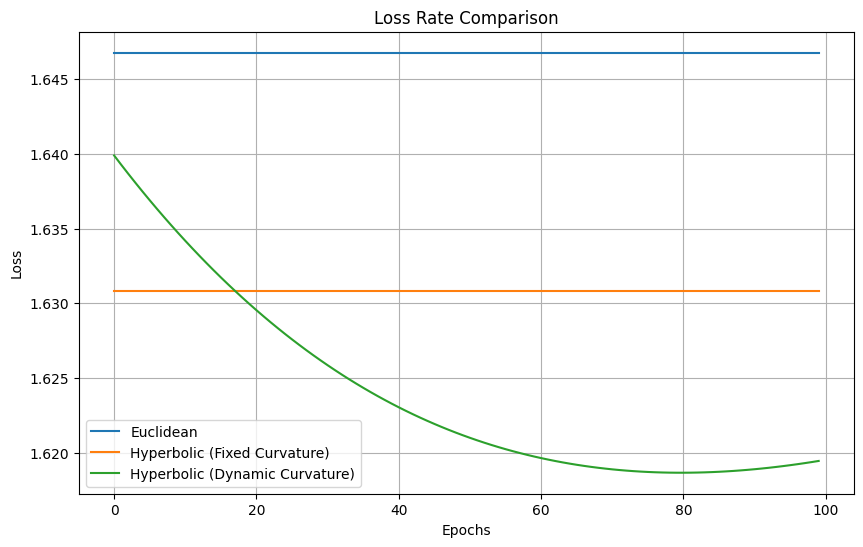

Clustering Comparison for Hyperbolic Model (Fixed Curvature):


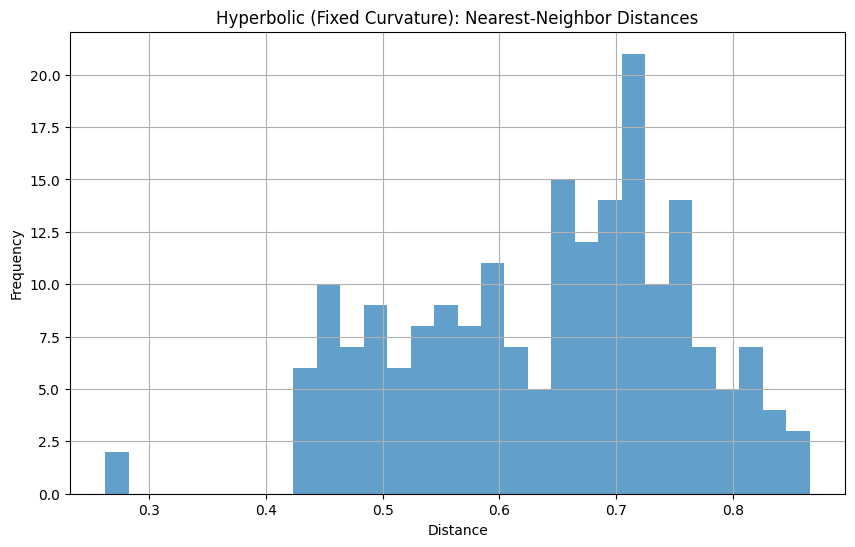

Clustering Comparison for Hyperbolic Model (Dynamic Curvature):


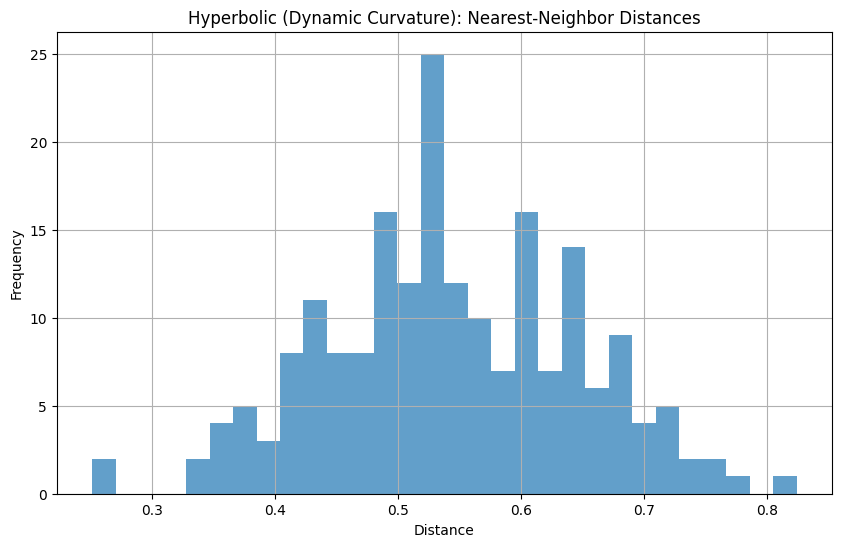

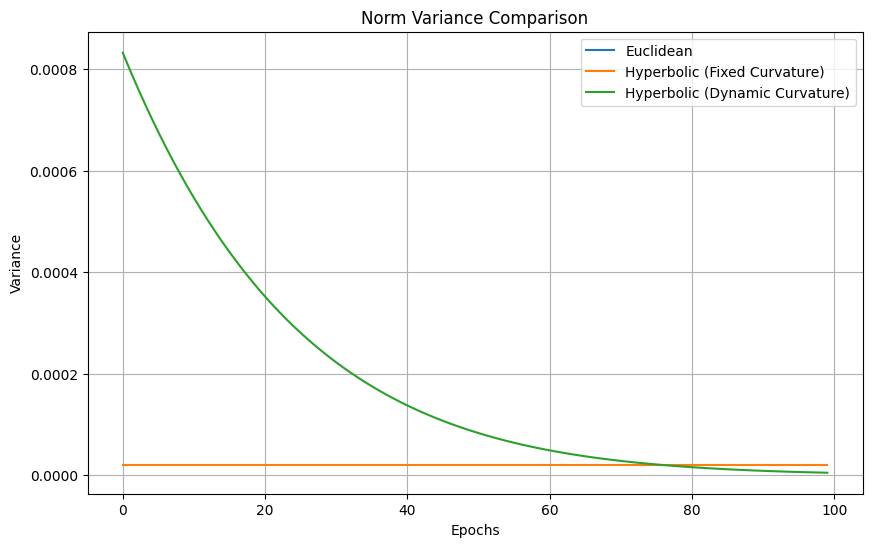

In [ ]:
import torch
import torch.nn.functional as F
import geoopt
from geoopt.manifolds import PoincareBall
from geoopt.manifolds.stereographic.math import mobius_matvec
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances


# Mobius Linear Layer
class MobiusLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, c=1.0):
        super(MobiusLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.c = c
        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) / np.sqrt(in_features))
        self.bias = torch.nn.Parameter(torch.zeros(out_features))
        self.manifold = PoincareBall(c=c)

    def forward(self, x):
        k = torch.tensor(-self.c, dtype=x.dtype, device=x.device)
        res = mobius_matvec(self.weight, x, k=k)
        res = self.manifold.mobius_add(res, self.bias)
        return res

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.c = new_c
        self.manifold = PoincareBall(c=new_c)


# Hyperbolic Layer
class HyperbolicLayer(torch.nn.Module):
    def __init__(self, input_dim, output_dim, curvature=1.0):
        super(HyperbolicLayer, self).__init__()
        self.curvature = curvature
        self.encoder = MobiusLinear(input_dim, output_dim, c=curvature)
        self.decoder = MobiusLinear(output_dim, input_dim, c=curvature)

    def forward(self, x):
        x_hyperbolic = self.encoder.manifold.expmap0(x)
        encoded = self.encoder(x_hyperbolic)
        decoded = self.decoder(encoded)
        x_euclidean = self.decoder.manifold.logmap0(decoded)
        return x_euclidean, encoded

    def update_curvature(self, new_c):
        """Update curvature for both encoder and decoder."""
        self.encoder.update_curvature(new_c)
        self.decoder.update_curvature(new_c)


# Curvature-Adaptive Optimizer
class CurvatureAdaptiveOptimizer(torch.optim.Optimizer):
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        if not 0.0 <= weight_decay:
            raise ValueError(f"Invalid weight decay value: {weight_decay}")

        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        self.curvature_history = []
        super().__init__(params, defaults)

    def step(self, curvature=None, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        # Record current curvature
        if curvature is not None:
            self.curvature_history.append(curvature)

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                # Perform optimization step
                grad = p.grad.data
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_avg_sq'] = torch.zeros_like(p.data)

                beta1, beta2 = group['betas']
                state['step'] += 1

                # Decay the first and second moment running average coefficient
                state['exp_avg'].mul_(beta1).add_(grad, alpha=1 - beta1)
                state['exp_avg_sq'].mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # Adaptive learning rate
                denom = (state['exp_avg_sq'].sqrt() / math.sqrt(1 - beta2 ** state['step'])) + group['eps']

                # Curvature-based adaptive scaling
                if curvature is not None:
                    # Adjust learning rate based on curvature
                    curvature_factor = 1.0 / (1 + abs(curvature))
                    step_size = group['lr'] * curvature_factor * (math.sqrt(1 - beta2 ** state['step']) / (1 - beta1 ** state['step']))
                else:
                    step_size = group['lr'] * (math.sqrt(1 - beta2 ** state['step']) / (1 - beta1 ** state['step']))

                # Weight decay
                if group['weight_decay'] != 0:
                    p.data.mul_(1 - group['lr'] * group['weight_decay'])

                # Update parameters
                p.data.addcdiv_(state['exp_avg'], denom, value=-step_size)

        return loss


# Neural Network with Hyperbolic Embedding
class HyperbolicNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, curvature=1.0, dynamic_curvature=False):
        super(HyperbolicNetwork, self).__init__()
        self.curvature = curvature
        self.dynamic_curvature = dynamic_curvature
        self.hyperbolic_layer = HyperbolicLayer(input_dim, hidden_dim, curvature=curvature)
        self.classifier = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, return_embeddings=False):
        x, embeddings = self.hyperbolic_layer(x)
        if return_embeddings:
            return embeddings
        return self.classifier(embeddings)

    def update_curvature(self, new_c):
        """Update curvature dynamically."""
        self.hyperbolic_layer.update_curvature(new_c)
        self.curvature = new_c


# Neural Network with Euclidean Embedding
class EuclideanNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(EuclideanNetwork, self).__init__()
        self.linear1 = torch.nn.Linear(input_dim, hidden_dim)
        self.linear2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        return self.linear2(x)


# Train Model with Curvature-Adaptive Optimizer
def train_model(model, data, labels, epochs=100, lr=0.001, curvature_scaling=False):
    # Use the new CurvatureAdaptiveOptimizer
    optimizer = CurvatureAdaptiveOptimizer(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    all_losses = []
    all_embeddings = []
    all_norm_variances = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, labels)

        # Hyperbolic-specific: Regularize embedding norms
        if hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            norms = embeddings.norm(dim=1)
            horizon_loss = torch.mean((norms - 1.0) ** 2)
            loss += 0.1 * horizon_loss

            # Dynamic curvature adjustment
            if curvature_scaling and hasattr(model, "update_curvature"):
                new_c = model.curvature * 1.01  # Slightly increase curvature
                model.update_curvature(new_c)

                # Pass curvature to optimizer for adaptive scaling
                optimizer.step(curvature=new_c)
            else:
                optimizer.step()

            # Track variance of norms
            norm_variance = torch.var(norms).item()
            all_norm_variances.append(norm_variance)

        loss.backward()

        all_losses.append(loss.item())

        # Save embeddings every 10 epochs
        if epoch % 10 == 0 and hasattr(model, "hyperbolic_layer"):
            embeddings = model(data, return_embeddings=True)
            all_embeddings.append(embeddings)

    return all_losses, all_embeddings, all_norm_variances


# Compare Loss Rates
def plot_loss_rates(euclidean_losses, hyperbolic_losses, dynamic_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(euclidean_losses, label="Euclidean")
    plt.plot(hyperbolic_losses, label="Hyperbolic (Fixed Curvature)")
    plt.plot(dynamic_losses, label="Hyperbolic (Dynamic Curvature)")
    plt.title("Loss Rate Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


def plot_clustering(embeddings, labels, title="Clustering Comparison"):
    with torch.no_grad():
        # Convert embeddings to NumPy and compute pairwise distances
        embeddings = embeddings.detach().cpu().numpy()
        pairwise_dist = pairwise_distances(embeddings)

        # Replace diagonal (self-distances) with infinity to exclude them
        np.fill_diagonal(pairwise_dist, np.inf)

        # Compute nearest-neighbor distances
        nearest_distances = np.min(pairwise_dist, axis=1)

        # Filter out NaN or infinite values (if any)
        nearest_distances = nearest_distances[np.isfinite(nearest_distances)]

    if nearest_distances.size == 0:
        print(f"No valid nearest-neighbor distances found for {title}. Skipping plot.")
        return

    # Plot histogram of nearest-neighbor distances
    plt.figure(figsize=(10, 6))
    plt.hist(nearest_distances, bins=30, alpha=0.7, label=title)
    plt.title(f"{title}: Nearest-Neighbor Distances")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

# Plot Variance in Embedding Norms
def plot_norm_variances(euclidean_variances, hyperbolic_variances, dynamic_variances):
    plt.figure(figsize=(10, 6))
    plt.plot(euclidean_variances, label="Euclidean")
    plt.plot(hyperbolic_variances, label="Hyperbolic (Fixed Curvature)")
    plt.plot(dynamic_variances, label="Hyperbolic (Dynamic Curvature)")
    plt.title("Norm Variance Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Variance")
    plt.legend()
    plt.grid()
    plt.show()

# Main modification is to add CurvatureAdaptiveOptimizer
def main():
    input_dim = 10
    hidden_dim = 20
    output_dim = 5
    num_samples = 200
    epochs = 100

    # Generate synthetic data
    data = torch.randn(num_samples, input_dim)
    labels = torch.randint(0, output_dim, (num_samples,))

    # Train Euclidean Model
    euclidean_model = EuclideanNetwork(input_dim, hidden_dim, output_dim)
    euclidean_losses, _, euclidean_variances = train_model(euclidean_model, data, labels, epochs)

    # Train Hyperbolic Model (Fixed Curvature)
    hyperbolic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=1.0)
    hyperbolic_losses, hyperbolic_embeddings, hyperbolic_variances = train_model(hyperbolic_model, data, labels, epochs)

    # Train Hyperbolic Model (Dynamic Curvature)
    hyperbolic_dynamic_model = HyperbolicNetwork(input_dim, hidden_dim, output_dim, curvature=0.5, dynamic_curvature=True)
    dynamic_losses, dynamic_embeddings, dynamic_variances = train_model(
        hyperbolic_dynamic_model, data, labels, epochs, curvature_scaling=True
    )

    # Plot Loss Rates
    plot_loss_rates(euclidean_losses, hyperbolic_losses, dynamic_losses)

    # Plot Clustering
    print("Clustering Comparison for Hyperbolic Model (Fixed Curvature):")
    plot_clustering(hyperbolic_embeddings[-1], labels, "Hyperbolic (Fixed Curvature)")
    print("Clustering Comparison for Hyperbolic Model (Dynamic Curvature):")
    plot_clustering(dynamic_embeddings[-1], labels, "Hyperbolic (Dynamic Curvature)")

    # Plot Variance in Embedding Norms
    plot_norm_variances(euclidean_variances, hyperbolic_variances, dynamic_variances)


if __name__ == "__main__":
    main()